# How Does AI Adoption Rate Compare with Productivity Change?
### ENGE707 Phase 1 — Data Engineering & Exploratory Data Analysis
#### Avathanshu Bhat : 23227963

**Dataset:** AI Company Adoption survey (`ai_company_adoption.csv`) — 150,000 quarterly
company records, 43 columns, 2023–2026.
Link: https://www.kaggle.com/datasets/mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset

**Scope note.** This notebook has been narrowed following the lecturer's Phase 1 feedback that
the earlier draft (maturity, ethics governance, workforce displacement, investment, etc.) covered
too many variables at once. Only two columns are analysed from here on:

| Role | Column | Meaning |
|---|---|---|
| Focus variable 1 | `ai_adoption_rate` | % of a company's operations/processes that use AI |
| Focus variable 2 | `productivity_change_percent` | % change in productivity subsequently reported |

Everything below stops at the same point the written report stops: the correlation heatmap.
Anything that isn't part of that two-variable deliverable (secondary/tertiary feature profiling,
adoption-stage cross-tabs, investment-per-employee outlier work, etc.) has been removed rather
than just left unused, so this notebook and the report describe the same pipeline end to end.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

pd.set_option("display.max_columns", 50)

## Task 1 — Problem Definition and Dataset Selection

- **Source:** AI Company Adoption dataset (Kaggle-style open synthetic survey), provided as
  `ai_company_adoption.csv`.
- **Structure:** tabular, alphanumeric, 150,000 rows × 43 columns — satisfies the ">20 and
  <300 features" requirement.
- **Unit of observation:** one row = one company's survey response for one quarter (a company
  can appear multiple times, once per quarter, identified by `company_id`).
- **Research question:** how does a company's AI adoption rate compare with the productivity
  change it subsequently reports?
- **Stakeholders:** company leadership deciding AI budgets, technology investment committees,
  policymakers (e.g. OECD) tracking whether AI investment is producing measurable returns.

## Task 2 — Data Acquisition, Inspection, and Documentation

### 2.1 Load and inspect structure

In [2]:
df = pd.read_csv("ai_company_adoption.csv")

print("Shape:", df.shape)
df.head()

Shape: (150000, 43)


,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,company_founding_year,company_age,company_age_group,ai_adoption_rate,ai_adoption_stage,years_using_ai,ai_primary_tool,num_ai_tools_used,ai_use_case,ai_projects_active,ai_training_hours,ai_budget_percentage,ai_maturity_score,ai_failure_rate,ai_investment_per_employee,regulatory_compliance_score,data_privacy_level,ai_ethics_committee,ai_risk_management_score,remote_work_percentage,employee_satisfaction_score,task_automation_rate,time_saved_per_week,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,1994,29,16-30 years,30.57,pilot,3,ChatGPT,1,Customer Support,3,20.94,6.54,0.224,35.22,55392.29,60,Medium,No,60,14.55,6.95,19.47,6.44,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,1994,29,16-30 years,27.25,pilot,4,ChatGPT,3,Software Development,0,23.10,5.81,0.174,24.65,49210.79,68,High,No,53,50.25,5.16,26.24,8.92,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,1994,29,16-30 years,31.54,pilot,2,Custom Internal AI,3,HR Automation,3,12.29,12.39,0.266,36.51,105011.76,66,High,No,53,41.70,4.57,22.24,7.59,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,1994,29,16-30 years,11.02,pilot,2,Custom Internal AI,1,Software Development,2,11.31,3.20,0.123,33.30,27157.71,64,High,No,44,28.10,5.33,2.87,3.16,5.32,1,1,2,8.19,0.00,51,5.72,Internal Corporate Survey,Research Compilation
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,1994,30,16-30 years,33.39,pilot,7,ChatGPT,3,Customer Support,5,35.17,9.98,0.363,19.83,84622.90,68,High,Yes,77,29.93,6.00,18.44,7.03,6.32,2,3,6,11.30,9.02,43,6.31,McKinsey Report,Research Compilation


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   response_id                  150000 non-null  int64  
 1   company_id                   150000 non-null  str    
 2   survey_year                  150000 non-null  int64  
 3   quarter                      150000 non-null  str    
 4   country                      150000 non-null  str    
 5   region                       150000 non-null  str    
 6   industry                     150000 non-null  str    
 7   company_size                 150000 non-null  str    
 8   num_employees                150000 non-null  int64  
 9   annual_revenue_usd_millions  150000 non-null  float64
 10  company_founding_year        150000 non-null  int64  
 11  company_age                  150000 non-null  int64  
 12  company_age_group            150000 non-null  str    
 13  ai_adoptio

In [4]:
# Structural summary (mirrors report Table 1)
dtype_counts = df.dtypes.value_counts()
print("Column dtype counts:")
print(dtype_counts)

print("\nColumns spanning:", df["country"].nunique(), "countries and",
      df["industry"].nunique(), "industries")
print("Company size categories:", df["company_size"].unique().tolist())

Column dtype counts:
float64    15
int64      14
str        14
Name: count, dtype: int64

Columns spanning: 30 countries and 9 industries
Company size categories: ['Startup', 'Enterprise', 'SME']


The dataset spans 30 countries and 9 industries and separates companies into three size
categories. This categorical variety isn't used directly in the narrowed two-variable comparison,
but it confirms the sample is broad rather than a narrow convenience sample. `quarter` is the only
column converted to `category` dtype below, since the other categorical columns (industry,
country, survey_source, etc.) sit outside this narrowed comparison's working table.

In [5]:
df["quarter"] = df["quarter"].astype("category")

df_original = df.copy(deep=True)
print("Records:", df_original.shape[0])
print("Columns:", df_original.shape[1])

Records: 150000
Columns: 43


### 2.2 Data-quality inspection of the focus variables

In [6]:
focus = ["ai_adoption_rate", "productivity_change_percent"]

# Missing values
print("Missing values in focus variables:")
print(df_original[focus].isna().sum())

# Duplicate rows / duplicate response IDs
print("\nFully duplicate rows:", df_original.duplicated().sum())
print("Duplicate response_id values:", df_original["response_id"].duplicated().sum())

# Value ranges
print("\nValue ranges:")
print(df_original[focus].agg(["min", "max"]).T)

Missing values in focus variables:
ai_adoption_rate               0
productivity_change_percent    0
dtype: int64



Fully duplicate rows: 0
Duplicate response_id values: 0

Value ranges:
                             min     max
ai_adoption_rate             0.0  100.00
productivity_change_percent  0.0   34.36


**Findings:** neither `ai_adoption_rate` nor `productivity_change_percent` has a missing
value across all 150,000 records, and there are no fully duplicate rows or duplicate
`response_id` values. `ai_adoption_rate` runs 0–100%, matching its definition as a percentage.
`productivity_change_percent` runs 0–34.36%, with no negative values, so neither variable needed
an out-of-range correction at this stage.

### 2.3 Assumptions documented during inspection

1. **Panel structure.** `company_id` repeats across quarters (10,000 companies, each responding
   an unequal number of times), so this is treated as an unbalanced panel rather than 150,000
   independent observations — revisited as a limitation later.
2. **Licence.** The Kaggle listing did not state a specific open licence at the time of access,
   so the dataset is treated as intended for the educational/research use described on its
   landing page.

## Task 3 — Data Cleansing and Transformation

### 3.1 Cleaning decisions

Because Task 2 found no missing values, duplicates, or invalid records in the focus variables,
`clean_data()` below is deliberately narrow: it is a safeguard against a missing/out-of-range
`ai_adoption_rate`, a de-duplication step, and — most importantly — the transformation that
actually narrows the working table down to the two focus variables plus three identifier columns
kept for traceability (`response_id`, `company_id`, `survey_year`). Narrowing the table is treated
as being as important a cleaning decision as removing an invalid value, since it is the direct
response to the Phase 1 scope-narrowing feedback.

In [7]:
def clean_data(data):
    clean = data.copy(deep=True)

    # Safeguard: drop any record with a missing or out-of-range ai_adoption_rate
    invalid = clean["ai_adoption_rate"].isna() | ~clean["ai_adoption_rate"].between(0, 100)
    print("Records removed for missing/out-of-range ai_adoption_rate:", invalid.sum())
    clean = clean.loc[~invalid].copy()

    clean = clean.drop_duplicates()

    # Narrow to the two focus variables + identifiers kept for traceability
    keep_cols = ["response_id", "company_id", "survey_year", "ai_adoption_rate",
                 "productivity_change_percent"]
    clean = clean[keep_cols].reset_index(drop=True)
    return clean


df_clean = clean_data(df_original)

print("\nOriginal shape:", df_original.shape)
print("Cleaned (narrowed) shape:", df_clean.shape)
df_clean.head()

Records removed for missing/out-of-range ai_adoption_rate: 0



Original shape: (150000, 43)
Cleaned (narrowed) shape: (150000, 5)


,response_id,company_id,survey_year,ai_adoption_rate,productivity_change_percent
0,1,COMP-00001,2023,30.57,2.65
1,2,COMP-00001,2023,27.25,5.77
2,3,COMP-00001,2023,31.54,6.94
3,4,COMP-00001,2023,11.02,5.32
4,5,COMP-00001,2024,33.39,6.32


### 3.2 Outlier investigation (interquartile range method)

In [8]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    below = (series < lower).sum()
    above = (series > upper).sum()
    return below, above, lower, upper


for col in focus:
    below, above, lower, upper = iqr_outliers(df_clean[col])
    pct = (below + above) / len(df_clean) * 100
    print(f"{col}: {below} below lower fence, {above} above upper fence "
          f"({pct:.2f}% of {len(df_clean)} records) | fence = [{lower:.2f}, {upper:.2f}]")

ai_adoption_rate: 0 below lower fence, 504 above upper fence (0.34% of 150000 records) | fence = [-3.23, 75.86]
productivity_change_percent: 0 below lower fence, 529 above upper fence (0.35% of 150000 records) | fence = [-7.00, 25.20]


Both variables' statistical outliers sit only above the upper fence (none below), and both
are well under 1% of records. These are retained rather than removed: they fall inside each
variable's valid documented range, so they represent genuinely high-adoption or high-productivity
companies rather than data-entry errors — and removing them would weaken the very relationship
this project narrowed down to examine.

### 3.3 ETL and ELT demonstration

In [9]:
# ETL: clean in pandas first, then load only the clean table
etl_conn = sqlite3.connect("etl_pipeline.db")
df_clean.to_sql("clean_ai_productivity", etl_conn, if_exists="replace", index=False)

# ELT: load the untouched raw table first, then transform on read
elt_conn = sqlite3.connect("elt_pipeline.db")
df_original.to_sql("raw_ai_adoption", elt_conn, if_exists="replace", index=False)
raw_from_db = pd.read_sql("SELECT * FROM raw_ai_adoption", elt_conn)
clean_from_db = clean_data(raw_from_db)
clean_from_db.to_sql("clean_ai_productivity", elt_conn, if_exists="replace", index=False)

etl_tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", etl_conn)
elt_tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", elt_conn)
print("ETL database tables:", etl_tables["name"].tolist())
print("ELT database tables:", elt_tables["name"].tolist())

etl_conn.close()
elt_conn.close()

Records removed for missing/out-of-range ai_adoption_rate: 0


ETL database tables: ['clean_ai_productivity']
ELT database tables: ['raw_ai_adoption', 'clean_ai_productivity']


The ETL database ends up with only the narrow, cleaned table. The ELT database keeps the
full 43-column raw table alongside the cleaned one — so if a later project phase needs a variable
outside this narrowed comparison, it's still sitting in the raw table without re-extracting the
source CSV.

## Task 4 — Exploratory Data Analysis and Visualisation

### 4.1 Descriptive statistics

In [10]:
desc = df_clean[focus].describe().round(2)
skew = df_clean[focus].skew().round(2)
print(desc)
print("\nSkewness:")
print(skew)

       ai_adoption_rate  productivity_change_percent
count         150000.00                    150000.00
mean              36.41                         9.27
std               14.54                         5.64
min                0.00                         0.00
25%               26.43                         5.07
50%               36.32                         9.06
75%               46.20                        13.12
max              100.00                        34.36

Skewness:
ai_adoption_rate               0.06
productivity_change_percent    0.30
dtype: float64


`ai_adoption_rate` has a mean of 36.41% and a standard deviation of 14.54%, with a skew of
0.06 — close to symmetric. `productivity_change_percent` has a mean of 9.27% and a standard
deviation of 5.64%, with a skew of 0.30 — a mild right-skew. These are read alongside the
visualisations below rather than as a conclusion on their own.

### 4.2 Distribution analysis

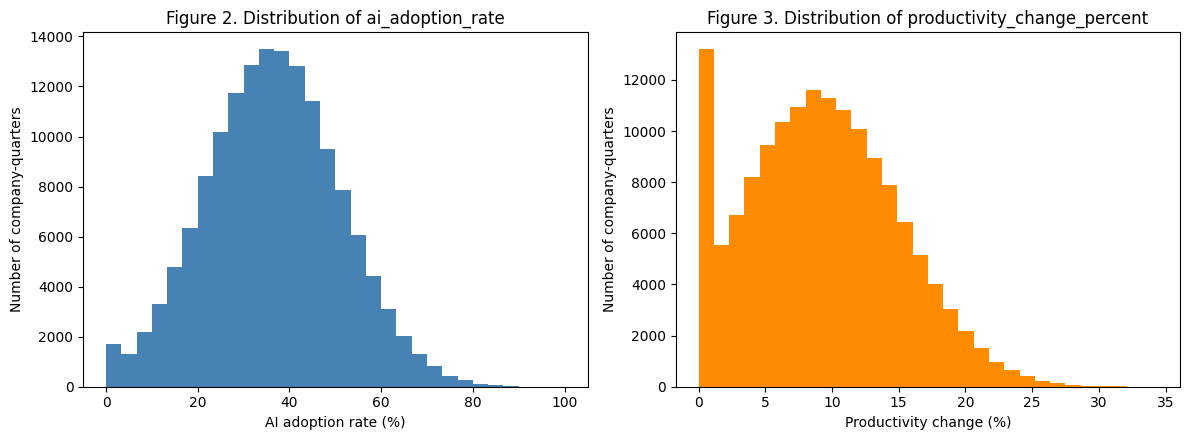

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df_clean["ai_adoption_rate"], bins=30, color="steelblue")
axes[0].set_xlabel("AI adoption rate (%)")
axes[0].set_ylabel("Number of company-quarters")
axes[0].set_title("Figure 2. Distribution of ai_adoption_rate")

axes[1].hist(df_clean["productivity_change_percent"], bins=30, color="darkorange")
axes[1].set_xlabel("Productivity change (%)")
axes[1].set_ylabel("Number of company-quarters")
axes[1].set_title("Figure 3. Distribution of productivity_change_percent")

plt.tight_layout()
plt.show()

`ai_adoption_rate` (Figure 2) is close to symmetric and peaks between 30% and 40%, with very
few companies near 0% or above 80% — consistent with its low skew.

`productivity_change_percent` (Figure 3) rises to a peak between 8% and 10% before tailing off
right toward 30%, matching its positive skew. There is also a **visible spike in the very first
bin (0–1%)** that sits higher than the bin immediately after it — investigated further below,
since it's large enough (over 9,000 records) to be more than noise.

In [12]:
zero_prod = df_clean[df_clean["productivity_change_percent"] == 0]
print("Records with exactly 0% productivity change:", len(zero_prod),
      f"({len(zero_prod) / len(df_clean) * 100:.1f}% of the cleaned dataset)")
print("\nAI adoption rate within this zero-productivity subgroup:")
print(zero_prod["ai_adoption_rate"].describe().round(2))
print("\nAI adoption rate across the full cleaned dataset (for comparison):")
print(df_clean["ai_adoption_rate"].describe().round(2))

Records with exactly 0% productivity change: 9027 (6.0% of the cleaned dataset)

AI adoption rate within this zero-productivity subgroup:
count    9027.00
mean       18.39
std        10.33
min         0.00
25%        10.92
50%        18.44
75%        25.54
max        60.45
Name: ai_adoption_rate, dtype: float64

AI adoption rate across the full cleaned dataset (for comparison):
count    150000.00
mean         36.41
std          14.54
min           0.00
25%          26.43
50%          36.32
75%          46.20
max         100.00
Name: ai_adoption_rate, dtype: float64


**Observation worth flagging for the team:** the 0%-productivity subgroup (6.0% of all
records) is not spread across the full adoption-rate range — its adoption rate tops out at
60.45%, against a full-sample maximum of 100%, and its mean adoption rate (18.4%) is roughly half
the full-sample mean (36.4%). In other words, reporting zero productivity change looks concentrated
among **lower-adoption** companies specifically, not scattered evenly across the adoption scale.
This is the kind of subgroup pattern the report's own Section 6.4 also noticed near the bottom of
the scatter plot — see the discrepancy note at the end of this notebook for how the two
descriptions of it differ.

### 4.3 Outlier analysis

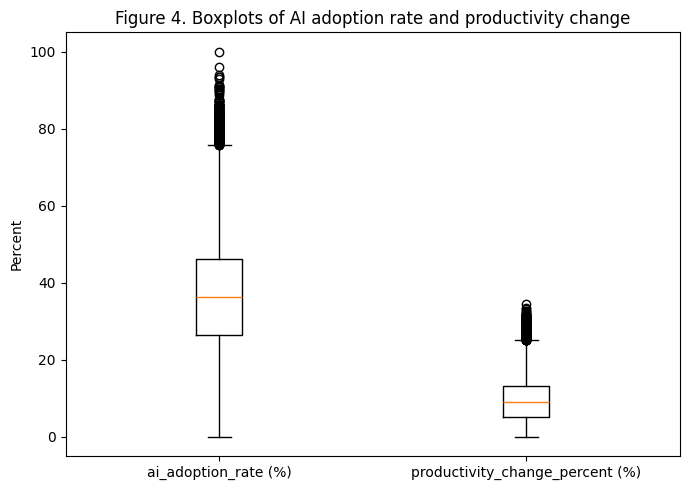

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([df_clean["ai_adoption_rate"], df_clean["productivity_change_percent"]],
           tick_labels=["ai_adoption_rate (%)", "productivity_change_percent (%)"])
ax.set_title("Figure 4. Boxplots of AI adoption rate and productivity change")
ax.set_ylabel("Percent")
plt.tight_layout()
plt.show()

Both boxplots show a compact middle 50% and a one-sided tail of points above the upper
whisker only, matching the IQR outlier counts in Task 3 and the mild positive skew already noted
for `productivity_change_percent`.

### 4.4 Relationship analysis

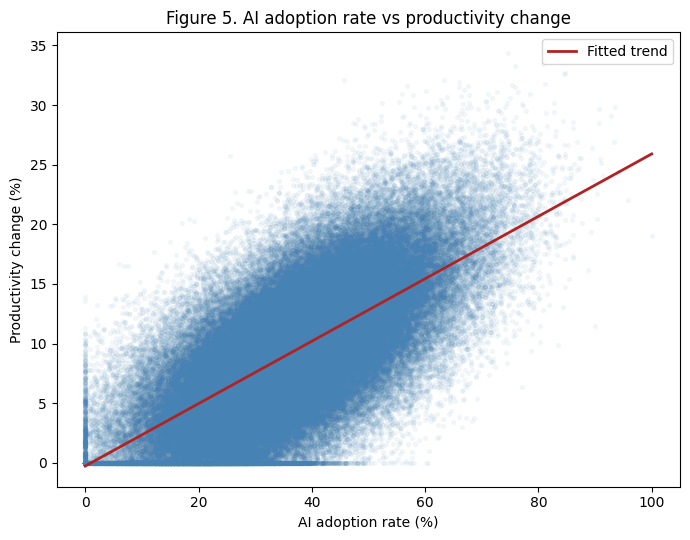

Pearson correlation coefficient: 0.675


In [14]:
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(df_clean["ai_adoption_rate"], df_clean["productivity_change_percent"],
           alpha=0.05, s=8, color="steelblue")

coeffs = np.polyfit(df_clean["ai_adoption_rate"], df_clean["productivity_change_percent"], 1)
trend_x = np.linspace(df_clean["ai_adoption_rate"].min(), df_clean["ai_adoption_rate"].max(), 100)
ax.plot(trend_x, np.polyval(coeffs, trend_x), color="firebrick", linewidth=2, label="Fitted trend")

ax.set_xlabel("AI adoption rate (%)")
ax.set_ylabel("Productivity change (%)")
ax.set_title("Figure 5. AI adoption rate vs productivity change")
ax.legend()
plt.tight_layout()
plt.show()

pearson_r = df_clean["ai_adoption_rate"].corr(df_clean["productivity_change_percent"])
print(f"Pearson correlation coefficient: {pearson_r:.3f}")

The point cloud rises from bottom-left to top-right, and the fitted trend line confirms a
positive, roughly linear relationship. The Pearson correlation coefficient is 0.675. Whether that
counts as "moderate" or "strong" depends on which convention you use (see discrepancy note at the
end); either way, the scatter around the trend line shows adoption rate alone doesn't fully
determine productivity change.

### 4.5 Grouped comparison

ai_adoption_rate
Low        5.63
Medium    11.64
High      18.98
Name: productivity_change_percent, dtype: float64


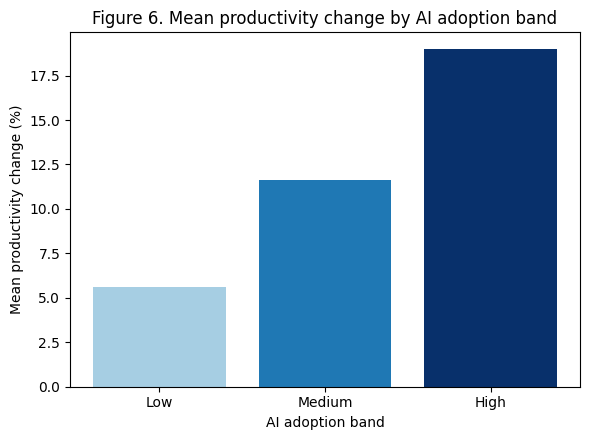

In [15]:
bins = [-0.01, 33.33, 66.67, 100]
labels = ["Low", "Medium", "High"]
band = pd.cut(df_clean["ai_adoption_rate"], bins=bins, labels=labels)

band_means = df_clean.groupby(band, observed=True)["productivity_change_percent"].mean()
print(band_means.round(2))

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(band_means.index.astype(str), band_means.values, color=["#a6cee3", "#1f78b4", "#08306b"])
ax.set_xlabel("AI adoption band")
ax.set_ylabel("Mean productivity change (%)")
ax.set_title("Figure 6. Mean productivity change by AI adoption band")
plt.tight_layout()
plt.show()

Mean productivity change rises step-wise from the Low to the High adoption band. This
grouped view derives entirely from the two focus variables — no new variable is introduced —
which keeps it consistent with the single-comparison scope.

### 4.6 Correlation heatmap

                             ai_adoption_rate  productivity_change_percent
ai_adoption_rate                        1.000                        0.675
productivity_change_percent             0.675                        1.000


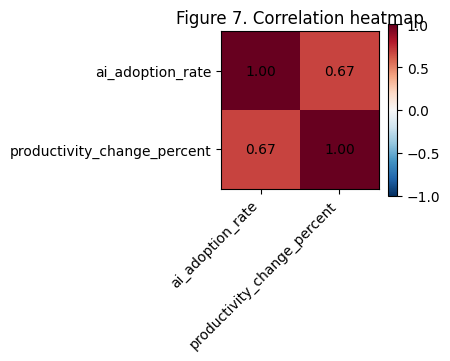

In [ ]:
corr_matrix = df_clean[focus].corr()
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(focus)))
ax.set_yticks(range(len(focus)))
ax.set_xticklabels(focus, rotation=45, ha="right")
ax.set_yticklabels(focus)
for i in range(len(focus)):
    for j in range(len(focus)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha="center", va="center")
ax.set_title("Figure 7. Correlation heatmap")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

The heatmap confirms the Pearson coefficient reported above — a second, visual confirmation
of the same relationship shown in the scatter plot.